<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Procesos-estocasticos/blob/main/tutorial_de_SymPy_y_NetworkX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tutorial de Sympy y Networkx

##SIMULACIÓN

**Estudiante:** Karla Michelle Soriano Sánchez

**Objetivo**: Explicar cómo representar matrices, obtener una entrada dada (columna, renglón o entrada especifica), multiplicar matrices, elevarlas a una potencia dada, multiplicar vectores por matrices y hallar valores y vectores propios, en la librería Sympy.

También que explicar cómo dibujar un diagrama de transición en la librería networkx.


La libreria de SymPy permite trabajar con matematicas simbolicas


In [43]:
import sympy as sp

# Crear una matriz

Para crear una matriz en SymPy, utilice el Matrix objeto . Una matriz se construye proporcionando una lista de vectores fila que la componen. Por ejemplo, para construir la matriz

In [44]:
A= sp.Matrix([[1,2,3],[4,5,6]])

"""
Matrix([[1,2,3],[4,5,6]]) indica que cada lista interna es un renglón de la matriz
La matrix A es de tamaño 3x3 porque tiene dos renglones y dos columnas.
Sympy muestra la matriz en formato
"""
A

Matrix([
[1, 2, 3],
[4, 5, 6]])

## Crear un vector columnas
Un vector en sympy es simplemente una matriz de una sola columna

In [45]:
v=sp.Matrix([2,4,6])
v

Matrix([
[2],
[4],
[6]])

## Obtener alguna entrada en especifico de la matriz

En python, los indices comienzan en $0$. En general los elementos de las matrices se denotan como:

$$ A[i,j]$$
donde:

*  $i$ es el número de fila
* $j$ es el número de columna

In [46]:
# Elemento $a_{1,1}$ en fila 1 y columna 1, es decir se trata de la posición [0,0]

A[0,0]

1

In [47]:
# Elemento en fila 2, columna 1, se trata de la posición [1,0]
A[1,0]

4

## Obtener una columna completa en especifico


In [48]:
A.col(2)

Matrix([
[3],
[6]])

#Obtener una fila completa

In [49]:
A.row(0)

Matrix([[1, 2, 3]])

##Multiplicación de matrices.

La multipliación matricial sigue la regla:

$
(AB)_{ij} = \sum_{k} A_{ik} B_{kj}
$


Es decir, el elemento en la posición $(i,j)$ de la matrix producto se obtiene sumando los productos de los elementos que corresponde a la fila $i$ de $A$ con los elementos de la columna $j$ de $B$

Por otro lado las dimensiones deben ser compatibles, es decir si:

$$
A \in \mathbb{R}^{m \times n}
\quad \text{y} \quad
B \in \mathbb{R}^{n \times p},
$$

entonces el producto $AB$ está definido y

$$
AB \in \mathbb{R}^{m \times p}.
$$

In [50]:
#definimos otra matriz la cual la llamare B
B = sp.Matrix ([[2,0], [1,2], [0,2]])

"""
En este caso la matriz A es de tamaño 2x3 y
la matriz B es de tamaño 3x2.
Por lo que coinciden las columnas A con las filas de B
El resultado del procuto es de tamaño 2x2


"""

#multipliacion matricial
A*B

Matrix([
[ 4, 10],
[13, 22]])

#Elevar una matriz a una potencia $A^n$
Eso significa que multplicare la matriz por sí misma n veces.

Para ello es muy importante que la matriz deba ser cuadrada es decir el numero de filas coincida con el número de columnas, para que pueda satifacer las reglas de multiplicación.


In [51]:
# defino una matriz cuadrada 3x3
C= sp.Matrix([[1,2,0],[3,0,4],[5,6,7]])
C


Matrix([
[1, 2, 0],
[3, 0, 4],
[5, 6, 7]])

In [52]:
#Elevo la matriz C al cuadrado
C**2

Matrix([
[ 7,  2,  8],
[23, 30, 28],
[58, 52, 73]])

In [53]:
#elevo la matriz al cubo
C**3

Matrix([
[ 53,  62,  64],
[253, 214, 316],
[579, 554, 719]])

## Multiplicación de matriz por vector
Si A es de tamaño $2x3$ y el vector v es de tamaño $3x1$ entonces el resultado del producto es de tamaño $2x1$




In [54]:
#multipliacion de Cv
A*v

Matrix([
[28],
[64]])

## Valores y vectores propios

Sea  

$$
A \in \mathbb{R}^{n \times n}
$$

una matriz cuadrada.

Un número $\lambda$ es un **valor propio** de $A$ si existe un vector no nulo  
$v \neq 0$ tal que:

$
M v = \lambda v
$

El vector $v$ se llama **vector propio** asociado a $\lambda$.



Consideremos la matriz:

$$
A =
\begin{pmatrix}
4 & 1 \\
2 & 3
\end{pmatrix}
$$

In [55]:
A= sp.Matrix ([[4, 1],
               [2, 3]])
A

Matrix([
[4, 1],
[2, 3]])

### Valores propios

**¿Cómo se obtienen los valores propios?**

Partimos de:
$$
A v = \lambda v
$$

Reescribimos:

$$
A v - \lambda v = 0
$$

Factorizamos:

$$
(A - \lambda I)v = 0
$$

Para que exista una solución no trivial $v \neq 0$, debe cumplirse:

$$
\det(A - \lambda I) = 0
$$

A esta ecuación se le llama **ecuación característica**.


In [56]:
# Definimos la variable lambda
λ = sp.symbols('lambda')

# Matriz identidad
I = sp.eye(2)

# Calculamos M - lambda I
A - λ*I

Matrix([
[4 - lambda,          1],
[         2, 3 - lambda]])

Calculare el determinante $|A - λ I|$, lo cual me produce la ecuación caracteristica

In [66]:
# Determinante de (M - lambda I)
polinomio_caract = (A - λ*I).det()
polinomio_caract

lambda**2 - 7*lambda + 10

Resolver la ecuación caracteristica tambien conocido como polinomio caracteristicos. Para elloe encontrare las raices que la satisfacen


In [67]:
# Resolvemos det(M - lambda I) = 0
valores_propios = sp.solve(polinomio_caract, λ)
valores_propios

[2, 5]

Calculo directamente con SymPy tanto los valores propios como los vectores propios.

- Vectores propios

  {valor propio $λ$ : multiplicidad}

- Vector propio

  {valor propio, multplicidadad, lista de vectores propio}


In [58]:
A.eigenvals()

{5: 1, 2: 1}

In [59]:
A.eigenvects()

[(2,
  1,
  [Matrix([
   [-1/2],
   [   1]])]),
 (5,
  1,
  [Matrix([
   [1],
   [1]])])]

#Diagramas de trancisión con NetworkX
´networkx´ es una libreria de Python que permite trabajar con **grafos** (redes de nudos conectados por aristas).
En el contexto de la cadena de Markov:
- Cada nodo representa un **estado**
- Cada flecha representa una **transición **
- El número sobre la flecha es la **probabilidad de transición**


In [60]:
import networkx as nx  #libreria para grafos
import matplotlib.pyplot as plt  #libreria para graficar

## Crear grafo dirigido
Para cadenas de Markov necesitamos un grafo **dírigido**, porque las transiciones (aristas) tienen dirección.

DiGraph() crea un grafo

In [61]:
# Creamos un grafo dirigido
G = nx.DiGraph()

## Agregar nodos (estados)
Se estan definiendo 2 estados

$$S={s_1, s_2}$$

In [62]:
# Agregamos estados
G.add_nodes_from(["S1", "S2"])

## Agregar transiciones con probabilidad

Supongamos la matriz de transición

$$ P =
\begin{pmatrix}
0.5 & 0.5 \\
0.2 & 0.8
\end{pmatrix}
$$

Esto significa:

- De $S_1$ a $S_1$ → $0.5$
- De $S_1$ a $S_2$ → $0.5$
- De $S_2$ a $S_1$ → $0.2$
- De $S_2$ a $S_2$ → $0.8$

Cada fila representa el estado actual y cada columna el estado siguiente.  
Además, cada fila debe sumar 1:

$$
0.5 + 0.5 = 1
$$

$$
0.2 + 0.8 = 1
$$

Lo implementamos en `networkx` de la siguiente manera:

In [63]:
# Agregamos aristas con pesos (probabilidades)
G.add_edge("S1","S1", weight=0.5)
G.add_edge("S1","S2", weight=0.5)
G.add_edge("S2","S1", weight=0.2)
G.add_edge("S2","S2", weight=0.8)

El argumento ´weight´  alamacena la probabilidad

## Dibujar diagrama


- nx.draw() dibuja los nodos y aristas.

- get_edge_attributes() extrae los pesos.

- *draw_networkx_edge_labels*() coloca las probabilidades en las flechas.

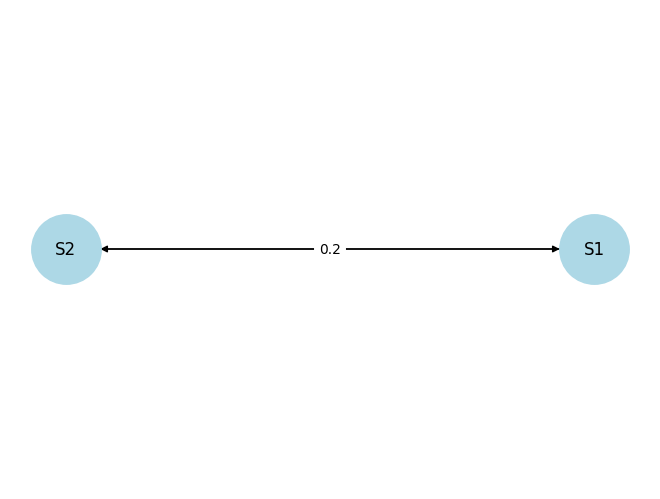

In [64]:
# Elegimos un diseño circular
pos = nx.circular_layout(G)

# Dibujamos el grafo
nx.draw(G, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=2500,
        font_size=12,
        arrows=True)

# Dibujamos las etiquetas de las probabilidades
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()

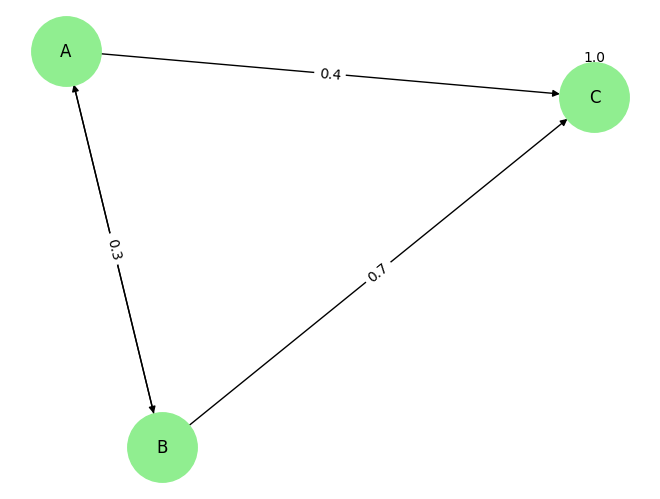

In [68]:
# Nuevo grafo
G2 = nx.DiGraph()

# Agregamos tres estados
G2.add_nodes_from(["A", "B", "C"])

# Agregamos transiciones
G2.add_edge("A","B", weight=0.6)
G2.add_edge("A","C", weight=0.4)
G2.add_edge("B","A", weight=0.3)
G2.add_edge("B","C", weight=0.7)
G2.add_edge("C","C", weight=1.0)

# Layout
pos = nx.spring_layout(G2)

# Dibujar
nx.draw(G2, pos,
        with_labels=True,
        node_color="lightgreen",
        node_size=2500,
        font_size=12,
        arrows=True)

labels = nx.get_edge_attributes(G2,'weight')
nx.draw_networkx_edge_labels(G2, pos, edge_labels=labels)

plt.show()

Un diagrama de transición representa gráficamente una matriz \( P \) donde:

$$
P_{ij} = \mathbb{P}(X_{n+1} = j \mid X_n = i)
$$

Es decir, $ P_{ij}$ representa la probabilidad de que el sistema pase
del estado $i$ en el tiempo $n$ al estado $ j$ en el tiempo $n+1$.

Cada fila de la matriz debe sumar 1, es decir,

$$
\sum_{j} P_{ij} = 1
\quad \text{para todo } i.
$$